# Complementary filter with Euler angles

Conceptually, sensor fusion consists of estimating a magnitude leveraging data from different sensors. In this case, the magnitudes of interest are roll and pitch, which will be later used to remove gravity from linear acceleration by trasforming the g vector to the device's reference frame and substracting it. 

The complementary filter is a simple way to do this, based on different characteristics of the sensors:

* Gyroscope: good short-term stability, but drifts in the long term.
* Accelerometer: good long-term stability, but noisy in the short term.

On continuous time, the idea is to apply a low-pass effect on the angle computed from accelerometer data and a high-pass effect on the integrated gyroscope data. On discrete time, this can be implemented with the following formula:

$$
\theta_t = \alpha (\theta_{t-1} + \omega_{t} \cdot \Delta t) + (1 - \alpha) \theta_{acc, t}
$$

Where $0 < \alpha < 1$ is a tuning parameter, and: $\alpha = \frac{\tau}{\tau + \Delta t}$, where $\tau$ is the time constant of the filter and $\Delta t$ is the sampling period.

In 3D space, considering the FLU (forwards, left, up) right-handed system of coordinates shown in the figure below:

<img src="../../docs/misc/roll-pitch-yaw.webp" alt="Coordinate system" width="250" height="250">

Using Euler angles, if the device is at rest and no other forces act on it aside from gravity, then the acceleration components at a given time instant are: 

  $$
    a_{x} = - g \cdot sin\ \theta_{acc, pitch}
  $$

  $$
  a_{y} = g \cdot sin\ \theta_{acc, roll} \cdot cos\ \theta_{acc, pitch}
  $$
  
  $$
  a_{z} = g \cdot cos\ \theta_{acc, roll} \cdot cos\ \theta_{acc, pitch}
  $$

Solving for the angles yield:

  $$
    \theta_{acc, roll} = atan2(a_{y}, a_{z})
  $$

  $$
    \theta_{acc, pitch} = atan2(-a_{x}, \sqrt{a_{y}^2 + a_{z}^2})
  $$

The angle $\theta_{acc, yaw}$ can't be computed from the accelerometer data, since the rotation around the gravity vector is unobservable from acceleration.  Another point of reference, such as a magnetometer, would be needed to compute this angle. As a consequence, the complementary filter can only be applied to roll and pitch angles, while the yaw angle can only be computed from the gyroscope data. However, since common calisthenics movements happen mostly on the sagital plane and a minor set on the frontal plane of the human body, the XY plane can be oriented to correspond with the plane of least importance, i.e. the transverse plane. As a reference, the following figure shows the three planes of movement of the human body: 

<img src="../../docs/misc/planes-of-motion-human-body.webp" alt="Coordinate system" width="400" height="300">

The formulas assume that gravity is the only force acting on the device, but that is not the case in this application. A possible solution could involve changing alpha to favor the gyroscope data more heavily when the device is in motion, and weigh the accelerometer more when the device is relatively stationary. A simple way to detect motion is to check that: $ | ||\mathbf{a}|| - g | > tol_{a} $ and $  ||\mathbf{\omega}|| > tol_{\omega} $, where $ tol_{a} $ and $ tol_{\omega} $ are tolerance values that can be obtained from computing the standard deviations of norms a set of stationary samples and then multiplying it by some factor. More complex methods (e.g. discard samples at the beginning and end of a stationary interval, or requiring a minimum length) have been found to not be suitable because additional conditions may not be met at all with real exercise data.

Sources:

* ["The balance filter" by Shane Colton](../../docs/misc/Motion%20filters.pdf)

* ["Using an Accelerometer for inclination sensing" application note by Christopher Fisher](../../docs/misc/Accelerometer%20inclination.pdf)

* [Drone Control and the Complementary Filter by Brian Douglas](https://www.youtube.com/watch?v=whSw42XddsU)


## Setup

In [2]:
from signal_utils import (
    IMUSampleReader,
    IMUSampleWriter,
    IMUStationaryChecker,
)
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy import stats

SAMPLING_FREQUENCY = 30  # Hz
dt = 1 / SAMPLING_FREQUENCY

stationaryCaptures = [
    "../1-calibration/output/positive-x-up-calibrated.csv",
    "../1-calibration/output/negative-x-up-calibrated.csv",
    "../1-calibration/output/positive-y-up-calibrated.csv",
    "../1-calibration/output/negative-y-up-calibrated.csv",
    "../1-calibration/output/positive-z-up-calibrated.csv",
    "../1-calibration/output/negative-z-up-calibrated.csv",
]

simpleRotationsCaptures = [
    "./capture/rotation-x-hw.csv",
    "./capture/rotation-y-hw.csv",
    "./capture/rotation-z-hw.csv",
]

realExerciseCaptures = [
    "../exercise-reception/capture-apr-28-2026/dips-1.csv",
    "../exercise-reception/capture-apr-28-2026/dips-2.csv",
    "../exercise-reception/capture-apr-28-2026/dips-3.csv",
    "../exercise-reception/capture-apr-28-2026/pull-ups-1.csv",
    "../exercise-reception/capture-apr-28-2026/pull-ups-2.csv",
    "../exercise-reception/capture-apr-28-2026/pull-ups-3.csv",
    "../exercise-reception/capture-apr-28-2026/90-deg-push-ups-1.csv",
    "../exercise-reception/capture-apr-28-2026/90-deg-push-ups-2.csv",
]

reader = IMUSampleReader()
writer = IMUSampleWriter()
stationaryChecker = IMUStationaryChecker()

## Transform hardware frame to software frame

The mounted sensor on the first prototype is not actually in the coordinate system shown above, but with the +x axis pointing to the right, +y axis pointing down, and +z axis pointing forwards, so the frame has to be transformed through software with a linear transformation:

$$
\boldsymbol{a}_{software}
=
\begin{bmatrix}
0 & 0 & 1 \\
-1 & 0 & 0 \\
0 & -1 & 0
\end{bmatrix}
\cdot
\boldsymbol{a}_{hardware}
$$

$$
\boldsymbol{\omega}_{software}
=
\begin{bmatrix}
0 & 0 & 1 \\
-1 & 0 & 0 \\
0 & -1 & 0
\end{bmatrix}
\cdot
\boldsymbol{\omega}_{hardware}
$$
or more simply,
$$
\boldsymbol{a}_{x, software} = \boldsymbol{a}_{z, hardware} \newline
\boldsymbol{a}_{y, software} = -\boldsymbol{a}_{x, hardware} \newline
\boldsymbol{a}_{z, software} = -\boldsymbol{a}_{y, hardware}
$$
$$
\boldsymbol{\omega}_{roll, software} = \boldsymbol{\omega}_{yaw, hardware} \newline
\boldsymbol{\omega}_{pitch, software} = -\boldsymbol{\omega}_{roll, hardware} \newline
\boldsymbol{\omega}_{yaw, software} = -\boldsymbol{\omega}_{pitch, hardware}
$$

In [3]:
def transformHWToSWFrame(a, w):
    aHw = a.copy()
    wHw = w.copy()
    a[:, 0] = aHw[:, 2]
    a[:, 1] = -1 * aHw[:, 0]
    a[:, 2] = -1 * aHw[:, 1]

    w[:, 0] = wHw[:, 2]
    w[:, 1] = -1 * wHw[:, 0]
    w[:, 2] = -1 * wHw[:, 1]

## Analyze inverse tangent behavior

`math.atan2(y, x)` (or its vector form, `np.atan(y, x)`) returns the angle in the interval $[\pi, \pi]$ between the positive x axis and the point (x,y) in the plane (i.e. the angle of the vector from the origin to (x, y)). It differs from the regular `math.atan(y/x)` because it uses the signs of both arguments to determine the correct quadrant.

$$
\operatorname{atan2}(y,x)=\begin{cases}
\arctan\!\left(\dfrac{y}{x}\right) & x>0\\[6pt]
\arctan\!\left(\dfrac{y}{x}\right)+\pi & x<0,\ y\ge 0\\[6pt]
\arctan\!\left(\dfrac{y}{x}\right)-\pi & x<0,\ y<0\\[6pt]
+\dfrac{\pi}{2} & x=0,\ y>0\\[6pt]
-\dfrac{\pi}{2} & x=0,\ y<0\\[6pt]
\text{undefined} & x=0,\ y=0
\end{cases}
$$

Examples:
- `atan2(1,1) = π/4`  
- `atan2(1,-1) = 3π/4`  
- `atan2(-1,-1) = -3π/4`  
- `atan2(-1,1) = -π/4`  
- `atan2(0,-1) = π`

Problems:

1. The function is vulnerable to rapid oscillations when the angle moves close to the negative x axis (i.e. y close to 0 by excess or defect). To fix this, there are many options, from cheaper/simpler to more complex/expensive:

    * Use a tolerance band within which y = 0 is assigned. The tolerance can't larger than around $0.1-0.2 \, \frac{\text{m}}{\text{s}^2}$, as it would start to filter out real, human scale motions, like the initial phase of a walk, a gentle motion of a vehicle, etc. Also consider interaction the complementary filter's $\alpha$: the lower the $\alpha$, the lower the tolerance should be, as the accelerometer contribution is larger. (chosen option)

    * Use hysterisis (small non-linearity): the output depends on the current as well as previous inputs and/or the direction of the change. If y is positive and greater than a tolerance, switch to positive. If it's negative and less than a tolerance, switch to negative. Otherwise use a previous state.

    * Unwrap the angle so that it evolves continuously over time. Not necessary for this application.

    * Sin/cos filtering: compute the angle, then remap it to coordinates with cosine and sine functions for the x and y axes, respectively. Then apply an exponential smoothing effect on both series. Lastly recompute the angle with the inverse tangent function. 

2. Some special function evaluations (e.g. involving 0, infinity, NaN) depend on the implementation. 

Sources:
- <https://en.wikipedia.org/wiki/Atan2>

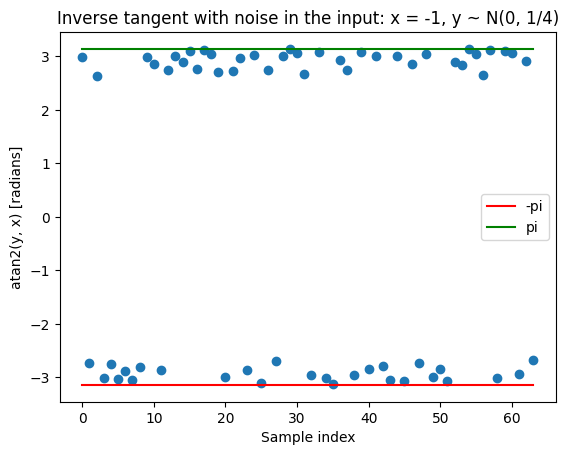

In [4]:
noiseSamples = 64
x = -1 * np.ones(noiseSamples)
y = stats.norm.rvs(loc=0, scale=1 / 4, size=noiseSamples)
plt.plot(np.atan2(y, x), "o")
plt.plot(-np.pi * np.ones(noiseSamples), "r", label="-pi")
plt.plot(np.pi * np.ones(noiseSamples), "g", label="pi")
plt.title("Inverse tangent with noise in the input: x = -1, y ~ N(0, 1/4)")
plt.xlabel("Sample index")
plt.ylabel("atan2(y, x) [radians]")
plt.legend()
plt.show()

In [5]:
print(f"Evaluation of atan2 function for special cases:")
print(f"atan2(1, 0) = {math.atan2(1, 0)}")
print(f"atan2(-1, 0) = {math.atan2(-1, 0)}")
print(f"atan2(0, 0) = {math.atan2(0, 0)}")
print(f"atan2(inf, 1) = {math.atan2(float('inf'), 1)}")
print(f"atan2(-inf, 1) = {math.atan2(float('-inf'), 1)}")
print(f"atan2(inf, -1) = {math.atan2(float('inf'), -1)}")
print(f"atan2(-inf, -1) = {math.atan2(float('-inf'), -1)}")
print(f"atan2(1, inf) = {math.atan2(1, float('inf'))}")
print(f"atan2(1, -inf) = {math.atan2(1, float('-inf'))}")
print(f"atan2(-1, inf) = {math.atan2(-1, float('inf'))}")
print(f"atan2(-1, -inf) = {math.atan2(-1, float('-inf'))}")

Evaluation of atan2 function for special cases:
atan2(1, 0) = 1.5707963267948966
atan2(-1, 0) = -1.5707963267948966
atan2(0, 0) = 0.0
atan2(inf, 1) = 1.5707963267948966
atan2(-inf, 1) = -1.5707963267948966
atan2(inf, -1) = 1.5707963267948966
atan2(-inf, -1) = -1.5707963267948966
atan2(1, inf) = 0.0
atan2(1, -inf) = 3.141592653589793
atan2(-1, inf) = -0.0
atan2(-1, -inf) = -3.141592653589793


## Estimate angles from accelerometer data

There are some edge cases:

1. The pitch formula has $\sqrt{a_{y}^2 + a_{z}^2}$ in the denominator. The square root is always non-negative, so the solution is limited to the interval $[-90°, 90°]$. This reflects a real ambiguity in the Euler-angle decomposition of gravity. In the case of the roll angle, the formula is limited to the interval $[-180°, 180°]$. To keep the complementary filter on the physically consistent branch, there are a couple of options:

* Use $a_{z}$ directly on the denominator of the pitch formula, but this is technically incorrect since the pitch would depend on the roll angle, which is not desirable.

* Use some form of sign-based unwrapping, but this may also be incorrect. 

* Compute the principal accelerometer solution together with its equivalent upside-down branch. Then use the gyroscope prediction to decide which branch is closer to the recent motion before applying the accelerometer correction. This approach improves branch selection, but near $pitch = \pm 90°$, the mapping becomes ill-conditioned, so small sensor noise can produce large angle changes. (chosen option)

2. Gimbal lock when $pitch = \pm 90°$, where the two other rotation axes become aligned and Euler angles lose a degree of freedom. This problem is inevitable. The only way to avoid it entirely is to use a different representation of orientation, such as quaternions.

Sources:
* <https://www.youtube.com/watch?v=zc8b2Jo7mno>
* <https://en.wikipedia.org/wiki/Gimbal_lock>


In [6]:
def angleDistanceInDegrees(a, b):
    return abs(wrapInDegrees(a - b))


def wrapInDegrees(angle):
    return (angle + 180.0) % 360.0 - 180.0


def modAtan2(y, x):
    accelTol = 0.15
    if abs(y) > accelTol:
        return math.atan2(y, x)
    else:
        return math.atan2(0, x)


def computeAccelAngleCandidates(ax, ay, az):
    mainRoll = 180 / np.pi * modAtan2(ay, az)
    mainPitch = 180 / np.pi * modAtan2(-ax, math.sqrt(ay**2 + az**2))

    alternativeRoll = wrapInDegrees(mainRoll + 180.0)
    alternativePitch = math.copysign(180.0 - abs(mainPitch), mainPitch)

    return (mainRoll, mainPitch), (alternativeRoll, alternativePitch)

## Estimate angles from gyroscope data

Compute it by simple integration for later comparison with the complementary filter. Use initial conditions from the accelerometer solution. Notice than the homogeneous solution is not always correct, since I may have started recording on a different position than neutral (sensor strapped to the chest). 

In [7]:
integrateEuler = lambda previous, midpoint, step: previous + midpoint * step


def gyroOnlyOrientation(a, w, dt):
    signalLength = w.shape[0]
    anglesGyro = np.zeros((signalLength, 3))
    (roll0, pitch0), _ = computeAccelAngleCandidates(a[0, 0], a[0, 1], a[0, 2])
    anglesGyro[0, 0] = roll0
    anglesGyro[0, 1] = pitch0
    for i in range(1, signalLength):
        anglesGyro[i, 0] = integrateEuler(anglesGyro[i - 1, 0], w[i, 0], dt)  # roll
        anglesGyro[i, 1] = integrateEuler(anglesGyro[i - 1, 1], w[i, 1], dt)  # pitch
        anglesGyro[i, 2] = integrateEuler(anglesGyro[i - 1, 2], w[i, 2], dt)  # yaw

    return anglesGyro

## Estimation movement detection tolerance

Agregate data from all stationary measurements and compute the mean and standard deviation of the norm of the acceleration and angular velocity vectors. The tolerances can be set to a multiple of the standard deviation. Based on the empirical rule, it should be at least 2 or 3 to cover most of the data. See: https://en.wikipedia.org/wiki/68%E2%80%9395%E2%80%9399.7_rule#Table_of_numerical_values

In [8]:
stationaryChecker.computeTolerances(stationaryCaptures)

Acceleration norms:	Mean = 9.806204
	Stdev = 0.040047
	Stationary tol = 0.200234
Gyroscope norms: 	Stdev = 2.590542
	Stationary tol = 7.771626


## Estimate angles with the complementary filter

1. The gyroscope is first integrated to predict the next roll and pitch angles. 

2. For each accelerometer sample, evaluate the principal Euler solution and its alternative branch, then compute a wrapped angular error against the gyroscope prediction. The branch with the lower aggregate roll/pitch error is used as the accelerometer correction. This is a local continuity heuristic rather than an exact distance on the full 3D rotation space, but it is a minimal way to keep the filter from snapping to the wrong pitch branch when the motion crosses $\pm 90°$. Near that region the estimate can still become noisy because Euler angles are close to their singular configuration.

3. Combine both estimates with the complementary filter formula, changing alpha depending on whether the device is in motion or not.    

In [9]:
def complementaryFilterOrientation(
    seq, a, w, dt, stationaryChecker, alphaStationary, alphaMoving
):
    signalLength = len(seq)
    anglesAccel = np.zeros((signalLength, 2))
    anglesComplementary = np.zeros((signalLength, 3), dtype=np.float32)
    (roll0, pitch0), _ = computeAccelAngleCandidates(a[0, 0], a[0, 1], a[0, 2])
    anglesComplementary[0, 0] = roll0
    anglesComplementary[0, 1] = pitch0

    for i in range(1, signalLength):
        ax = a[i, 0]
        ay = a[i, 1]
        az = a[i, 2]
        wroll = w[i, 0]
        wpitch = w[i, 1]
        wyaw = w[i, 2]

        predictedRollAngleGyro = integrateEuler(
            anglesComplementary[i - 1, 0], wroll, dt
        )
        predictedPitchAngleGyro = integrateEuler(
            anglesComplementary[i - 1, 1], wpitch, dt
        )
        anglesComplementary[i, 2] = integrateEuler(
            anglesComplementary[i - 1, 2], wyaw, dt
        )

        (mainRoll, mainPitch), (alternativeRoll, alternativePitch) = (
            computeAccelAngleCandidates(ax, ay, az)
        )
        mainError = angleDistanceInDegrees(
            mainRoll, predictedRollAngleGyro
        ) + angleDistanceInDegrees(mainPitch, predictedPitchAngleGyro)
        alternativeError = angleDistanceInDegrees(
            alternativeRoll, predictedRollAngleGyro
        ) + angleDistanceInDegrees(alternativePitch, predictedPitchAngleGyro)

        if mainError <= alternativeError:
            anglesAccel[i, 0] = mainRoll
            anglesAccel[i, 1] = mainPitch
        else:
            anglesAccel[i, 0] = alternativeRoll
            anglesAccel[i, 1] = alternativePitch

        continuousRollAngleAccel = predictedRollAngleGyro + wrapInDegrees(
            anglesAccel[i, 0] - predictedRollAngleGyro
        )
        continuousPitchAngleAccel = predictedPitchAngleGyro + wrapInDegrees(
            anglesAccel[i, 1] - predictedPitchAngleGyro
        )

        if stationaryChecker.isStationarySample(ax, ay, az, wroll, wpitch, wyaw):
            anglesComplementary[i, 0] = (
                alphaStationary * predictedRollAngleGyro
                + (1 - alphaStationary) * continuousRollAngleAccel
            )
            anglesComplementary[i, 1] = (
                alphaStationary * predictedPitchAngleGyro
                + (1 - alphaStationary) * continuousPitchAngleAccel
            )
        else:
            anglesComplementary[i, 0] = (
                alphaMoving * predictedRollAngleGyro
                + (1 - alphaMoving) * continuousRollAngleAccel
            )
            anglesComplementary[i, 1] = (
                alphaMoving * predictedPitchAngleGyro
                + (1 - alphaMoving) * continuousPitchAngleAccel
            )
    return (
        anglesAccel,
        anglesComplementary,
    )

## Grid search for filter parameters

Run the filter with different combinations of $\alpha_{stationary}$ and $\alpha_{moving}$ for later evaluation when gravity removal is applied to the linear acceleration. Export results to .csv files.

In [10]:
alphaStationaryArr = [0.75, 0.80, 0.85, 0.90, 0.95]
alphaMovingArr = [0.95, 0.975, 0.99]
for ast in alphaStationaryArr:
    for amv in alphaMovingArr:
        for capturePath in [
            *stationaryCaptures,
            *simpleRotationsCaptures,
            *realExerciseCaptures,
        ]:
            seq, a, w = reader.readRaw(capturePath)
            transformHWToSWFrame(a, w)
            _, complementaryAngles = complementaryFilterOrientation(
                seq, a, w, dt, stationaryChecker, ast, amv
            )

            filename = f"./output/ast={ast:.3f}-amv={amv:.3f}/{capturePath.split('/')[-1].split('.')[0]}-complementary.csv"
            writer.writeFiltered(filename, seq, a, w, complementaryAngles)

## Plot results as a time-series for a specific capture, $\alpha_{stationary}$ and $\alpha_{moving}$ 

In [11]:
from matplotlib.ticker import MultipleLocator

SMALL_ANGLE_RANGE_THRESHOLD = 3


def plotEulerAngles(
    seq, gyroAngles, accelAngles, complementaryAngles, stationaryIntervals, capturePath
):

    def configGraph(upperBound, lowerBound, axis, title):
        if lowerBound < -180:
            axis.axhline(-180, color="black", linestyle="-", linewidth=2.0, zorder=0)
        if lowerBound < -90:
            axis.axhline(-90, color="black", linestyle="-", linewidth=2.0, zorder=0)
        axis.axhline(0, color="black", linestyle="-", linewidth=2.0, zorder=0)
        if upperBound > 90:
            axis.axhline(90, color="black", linestyle="-", linewidth=2.0, zorder=0)
        if upperBound > 180:
            axis.axhline(180, color="black", linestyle="-", linewidth=2.0, zorder=0)
        axis.set_ylabel("Angle (degrees)")
        if upperBound - lowerBound > SMALL_ANGLE_RANGE_THRESHOLD:
            axis.yaxis.set_major_locator(MultipleLocator(15))

        axis.grid(True, which="both", linestyle="-", alpha=0.75)
        axis.set_xlabel("Sequence number")
        axis.set_title(title)

        for lower, upper in stationaryIntervals:
            axis.axvspan(lower, upper, color="tab:gray", alpha=0.25, zorder=0)

        axis.legend()

    lowerBoundRoll = min(
        accelAngles[:, 0].min(),
        gyroAngles[:, 0].min(),
        complementaryAngles[:, 0].min(),
    )
    upperBoundRoll = max(
        accelAngles[:, 0].max(),
        gyroAngles[:, 0].max(),
        complementaryAngles[:, 0].max(),
    )
    lowerBoundPitch = min(
        accelAngles[:, 1].min(), gyroAngles[:, 1].min(), complementaryAngles[:, 1].min()
    )
    upperBoundPitch = max(
        accelAngles[:, 1].max(), gyroAngles[:, 1].max(), complementaryAngles[:, 1].max()
    )
    lowerBoundYaw = gyroAngles[:, 2].min()
    upperBoundYaw = gyroAngles[:, 2].max()

    fig, axes = plt.subplots(3, 1, figsize=(16, 16))

    axes[0].plot(seq, accelAngles[:, 0], label="Acceleration-based")
    axes[0].plot(seq, gyroAngles[:, 0], label="Gyroscope-based")
    axes[0].plot(seq, complementaryAngles[:, 0], label="Complementary filter")
    configGraph(upperBoundRoll, lowerBoundRoll, axes[0], "Roll angle")

    axes[1].plot(seq, accelAngles[:, 1], label="Acceleration-based")
    axes[1].plot(seq, gyroAngles[:, 1], label="Gyroscope-based")
    axes[1].plot(seq, complementaryAngles[:, 1], label="Complementary filter")
    configGraph(upperBoundPitch, lowerBoundPitch, axes[1], "Pitch angle")

    axes[2].plot(seq, gyroAngles[:, 2], label="Gyroscope-based", color="#ff7f0e")
    configGraph(upperBoundYaw, lowerBoundYaw, axes[2], "Yaw angle")

    fig.suptitle(
        f"Euler angles estimation: {capturePath}\n(stationary intervals highlighted in gray)"
    )
    plt.tight_layout()
    plt.show()

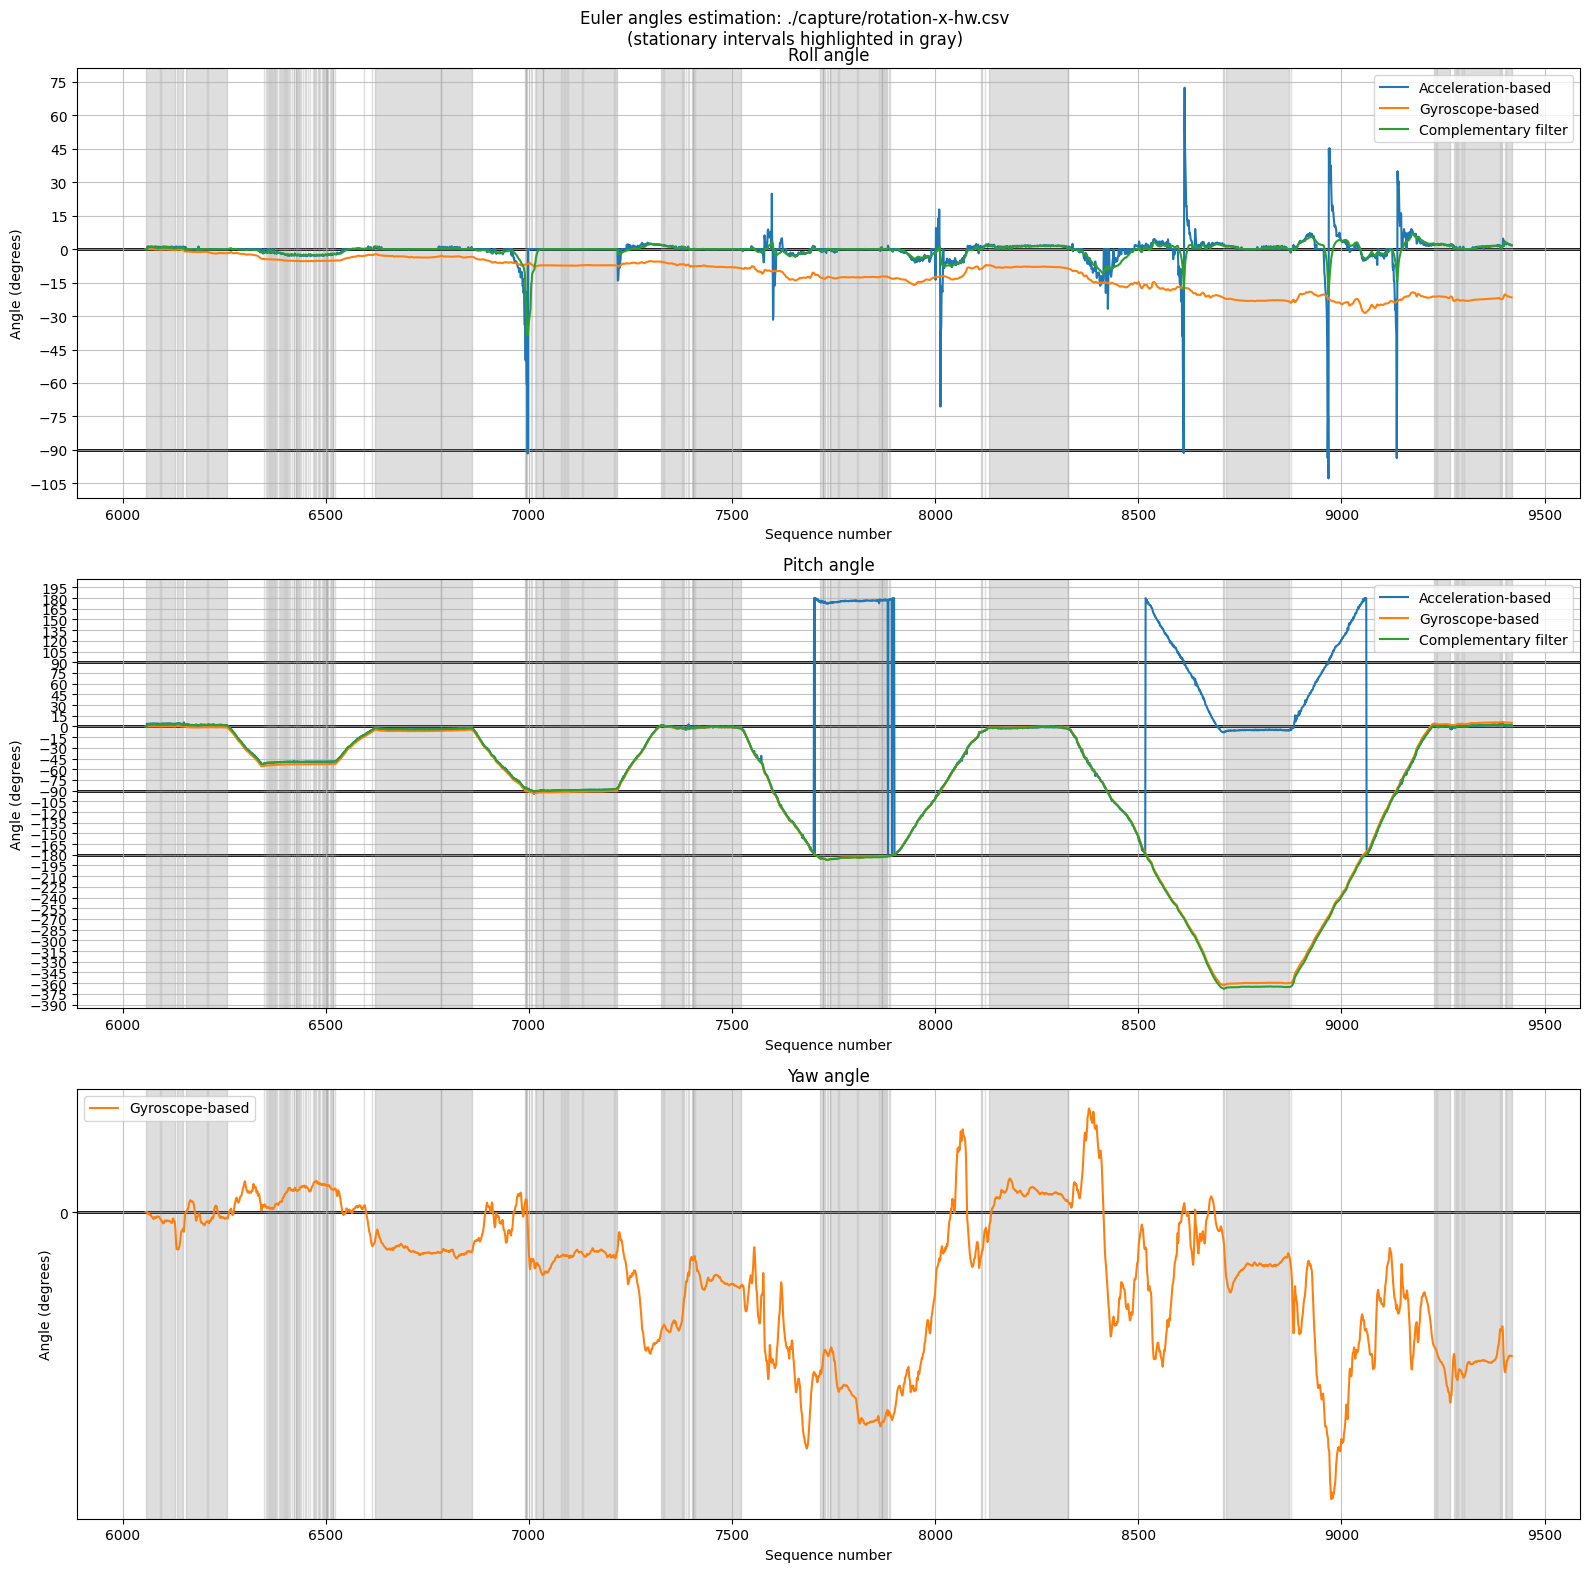

In [12]:
# Change index to visualize different captures
# capturePath = stationaryCaptures[0]
capturePath = simpleRotationsCaptures[0]
# capturePath = realExerciseCaptures[-1]
alphaStationary = 0.75
alphaMoving = 0.95

seq, a, w = reader.readRaw(capturePath)
transformHWToSWFrame(a, w)
gyroAngles = gyroOnlyOrientation(a, w, dt)
accelAngles, complementaryAngles = complementaryFilterOrientation(
    seq, a, w, dt, stationaryChecker, alphaStationary, alphaMoving
)
stationaryIntervals = stationaryChecker.findStationaryIntervals(seq, a, w)
plotEulerAngles(
    seq, gyroAngles, accelAngles, complementaryAngles, stationaryIntervals, capturePath
)

# Conclusion

After analyzing real exercises data against video recordings and getting a feeling of angles with a protractor, the complementary filter seems to work decently for the motions of this application. However, there are some limitations:

* Some angles are inherently problematic, namely $\pm 90^\circ$ and $\pm 180^\circ$.

* The workarounds discussed earlier (protection of atan2 against noise, motion detection, angle decision, two alphas) are not perfect and add some complexity and computation time, which goes against the goal of simplicity that was intended with this filter. 

A future iteration may consider a more advanced sensor fusion algorithm and another representation of orientation.